# 06 — Tuning, Validation and Fairness

This notebook implements the parts of the proposed methodology that the earlier notebooks
did not cover, and produces the evidence for the three research hypotheses.

| Proposal commitment | Where |
| --- | --- |
| Phase 2 — cleaning of duplicates and inconsistent dates | Section 1 |
| Phase 2 — class-imbalance handling with SMOTE | Section 4 |
| Phase 3 — grid search with stratified k-fold cross-validation | Section 5 |
| Phase 4 — temporally held-out test set | Section 2 |
| Phase 4 — accuracy, macro F1, ROC-AUC | Sections 3, 5 |
| Phase 4 — calibration plots | Section 6 |
| Phase 4 — fairness across genre sub-groups | Section 7 |

Reusable logic lives in `src/experiments.py`; `scripts/run_experiments.py` runs the same
pipeline headlessly and regenerates every CSV in `reports/results/`.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import confusion_matrix

from backend.app.training import prepare_model_frame
from src.evaluation import classification_metrics, metrics_by_group
from src.experiments import (
    build_baselines, calibration_table, compare_imbalance_strategies,
    fairness_summary, search_space, tune_model,
)
from src.preprocessing import clean_dataset, make_preprocessor

RESULTS = ROOT / "reports" / "results"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
FOLDS, MIN_GROUP_N = 5, 30

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("pandas", pd.__version__)

Matplotlib is building the font cache; this may take a moment.


pandas 3.0.2


## 1. Phase 2 — data cleaning

The source file carries two defects that matter. 78 rows are exact duplicates, and a large
minority carry a `first_week` date in the future — as far ahead as 2075. The second one is not
cosmetic: the temporal split below sorts on that column and takes the tail as the test set, so
leaving them in means the holdout is composed of corrupt rows rather than recent releases.

In [2]:
raw = pd.read_csv(ROOT / "data" / "raw" / "spotify.csv", low_memory=False)
_, report = clean_dataset(raw)
pd.DataFrame([report]).T.rename(columns={0: "value"})

,value
rows_in,29488
duplicates_dropped,78
unparseable_dates_dropped,0
future_dates_dropped,11159
cutoff,2026-08-17
date_min_before,1976-01-03
date_max_before,2075-12-27
date_min_after,1976-01-03
date_max_after,2021-05-29
rows_out,18251


Note the date range before and after: the maximum moves from 2075 back to a plausible value,
which is what makes the chronological split below meaningful.

## 2. Phase 4 — temporal holdout split

`prepare_model_frame` applies the cleaning, derives the label, sorts chronologically and drops
the leakage columns (chart position, weeks on chart, popularity). The last 20% is held out.

In [3]:
model_df = prepare_model_frame(raw)
split_idx = int(0.8 * len(model_df))

x_train = model_df.iloc[:split_idx].drop(columns=["hit"])
y_train = model_df.iloc[:split_idx]["hit"]
x_test  = model_df.iloc[split_idx:].drop(columns=["hit"])
y_test  = model_df.iloc[split_idx:]["hit"]

numeric = x_train.select_dtypes(include=["number"]).columns.tolist()
categorical = [c for c in x_train.columns if c not in numeric]
holdout_positive_rate = float(y_test.mean())

print(f"train {len(x_train):,} rows  positive rate {y_train.mean():.4f}")
print(f"test  {len(x_test):,} rows  positive rate {holdout_positive_rate:.4f}")
print(f"features: {len(numeric)} numeric, {len(categorical)} categorical")
print(f"encoded width: {make_preprocessor(numeric, categorical).fit_transform(x_train).shape[1]:,}")

train 14,600 rows  positive rate 0.1904
test  3,651 rows  positive rate 0.1090
features: 13 numeric, 4 categorical
encoded width: 2,816


The holdout positive rate is markedly lower than the training rate. That is a genuine temporal
shift — the hit rate in this dataset declines over the period — and it raises the majority-class
baseline on the test set, which the next section quantifies.

## 3. Baselines — the comparator H1 actually needs

H1 proposes beating "a random baseline". On an imbalanced target that is the wrong bar: a
classifier that always answers "not a hit" is far stronger than random. Both are fitted here so
the comparison is explicit.

In [4]:
baseline_rows = []
for name, dummy in build_baselines().items():
    dummy.fit(x_train[numeric].fillna(0), y_train)
    pred = dummy.predict(x_test[numeric].fillna(0))
    prob = dummy.predict_proba(x_test[numeric].fillna(0))[:, 1]
    baseline_rows.append({"model": name, **classification_metrics(y_test, pred, prob)})

baselines_df = pd.DataFrame(baseline_rows).set_index("model")
baselines_df.round(4)

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
model,,,,,
baseline_majority_class,0.8910,0.4455,0.5000,0.4712,0.5000
baseline_stratified_random,0.7406,0.4926,0.4884,0.4851,0.4884


## 4. Phase 2 — class-imbalance handling (SMOTE)

Three strategies are compared per model family with hyperparameters held fixed: no handling,
scikit-learn class weighting, and SMOTE oversampling.

SMOTE sits inside an `imblearn` pipeline rather than being applied to the data beforehand. That
distinction is the difference between a valid experiment and a leaked one: inside the pipeline,
resampling is fitted per training fold and never touches a validation fold or the holdout.

In [5]:
families = ["logistic_regression", "random_forest", "xgboost"]

imbalance = compare_imbalance_strategies(
    lambda: make_preprocessor(numeric, categorical),
    x_train, y_train, families, n_splits=FOLDS, verbose=True,
)
imbalance[["model", "imbalance", "f1_macro_mean", "f1_macro_std",
           "roc_auc_mean", "accuracy_mean"]].round(4)

  CV logistic_regression / imbalance=none …


  CV logistic_regression / imbalance=balanced …


  CV logistic_regression / imbalance=smote …


  CV random_forest / imbalance=none …


  CV random_forest / imbalance=balanced …


  CV random_forest / imbalance=smote …


  CV xgboost / imbalance=none …


  CV xgboost / imbalance=balanced …


  CV xgboost / imbalance=smote …


,model,imbalance,f1_macro_mean,f1_macro_std,roc_auc_mean,accuracy_mean
8,xgboost,smote,0.6705,0.0105,0.7474,0.8080
5,random_forest,smote,0.6620,0.0054,0.7474,0.8139
7,xgboost,balanced,0.6527,0.0063,0.7567,0.7517
2,logistic_regression,smote,0.6395,0.0057,0.7496,0.7276
0,logistic_regression,none,0.6377,0.0098,0.7577,0.8322
1,logistic_regression,balanced,0.6366,0.0040,0.7563,0.7205
6,xgboost,none,0.6350,0.0104,0.7593,0.8322
3,random_forest,none,0.6168,0.0052,0.7479,0.8284
4,random_forest,balanced,0.6069,0.0100,0.7508,0.8247


In [6]:
best_strategy = {
    f: imbalance[imbalance["model"] == f].sort_values("f1_macro_mean", ascending=False)
        .iloc[0]["imbalance"]
    for f in families
}
best_strategy

{'logistic_regression': 'smote', 'random_forest': 'smote', 'xgboost': 'smote'}

## 5. Phase 3 — grid search with stratified k-fold CV

Each family is tuned with `GridSearchCV` over `StratifiedKFold(5)`, scoring macro F1, fitted on
the **training portion only**. The holdout stays sealed and is scored once per family afterwards.

Reporting the fold standard deviation alongside the mean is what allows H2 to be judged: two
models whose means differ by less than the combined spread are not meaningfully different.

In [7]:
tuned, fitted = [], {}

for family in families:
    strategy = best_strategy[family]
    grid = search_space(family)
    combos = int(np.prod([len(v) for v in grid.values()])) if grid else 1
    print(f"{family} (imbalance={strategy}) — {combos} combinations x {FOLDS} folds")

    search = tune_model(make_preprocessor(numeric, categorical), x_train, y_train,
                        family, strategy, n_splits=FOLDS)
    i = int(search.best_index_)
    cv_mean = float(search.cv_results_["mean_test_score"][i])
    cv_std  = float(search.cv_results_["std_test_score"][i])

    model = search.best_estimator_
    fitted[family] = model
    pred = model.predict(x_test)
    prob = model.predict_proba(x_test)[:, 1]
    holdout = classification_metrics(y_test, pred, prob)

    print(f"  best params : {search.best_params_}")
    print(f"  CV f1_macro : {cv_mean:.4f} +/- {cv_std:.4f}")
    print(f"  holdout     : " + "  ".join(f"{k}={v:.4f}" for k, v in holdout.items()))

    tuned.append({"model": family, "imbalance": strategy,
                  "cv_f1_macro_mean": cv_mean, "cv_f1_macro_std": cv_std,
                  "best_params": json.dumps(search.best_params_), **holdout})

tuned_df = pd.DataFrame(tuned)
tuned_df[["model", "imbalance", "cv_f1_macro_mean", "cv_f1_macro_std",
          "accuracy", "f1_macro", "roc_auc"]].round(4)

logistic_regression (imbalance=smote) — 4 combinations x 5 folds


  best params : {'model__C': 0.1}
  CV f1_macro : 0.6439 +/- 0.0059
  holdout     : accuracy=0.6795  precision_macro=0.5714  recall_macro=0.6680  f1_macro=0.5496  roc_auc=0.7429
random_forest (imbalance=smote) — 8 combinations x 5 folds


  best params : {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
  CV f1_macro : 0.6628 +/- 0.0106
  holdout     : accuracy=0.7412  precision_macro=0.5863  recall_macro=0.6794  f1_macro=0.5876  roc_auc=0.7467
xgboost (imbalance=smote) — 8 combinations x 5 folds


  best params : {'model__learning_rate': 0.15, 'model__max_depth': 4, 'model__n_estimators': 200}
  CV f1_macro : 0.6683 +/- 0.0097
  holdout     : accuracy=0.7732  precision_macro=0.5922  recall_macro=0.6710  f1_macro=0.6024  roc_auc=0.7323


,model,imbalance,cv_f1_macro_mean,cv_f1_macro_std,accuracy,f1_macro,roc_auc
0,logistic_regression,smote,0.6439,0.0059,0.6795,0.5496,0.7429
1,random_forest,smote,0.6628,0.0106,0.7412,0.5876,0.7467
2,xgboost,smote,0.6683,0.0097,0.7732,0.6024,0.7323


In [8]:
# Evidence that resampling never reached the holdout.
assert float(y_test.mean()) == holdout_positive_rate
print(f"holdout positive rate unchanged at {holdout_positive_rate:.4f} — no resampling leak")

# The final model is selected on cross-validated score, never on the holdout.
best_name = tuned_df.loc[tuned_df["cv_f1_macro_mean"].idxmax(), "model"]
best_model = fitted[best_name]
print("selected by CV:", best_name)

holdout positive rate unchanged at 0.1090 — no resampling leak
selected by CV: xgboost


## 6. Phase 4 — calibration

A model can rank cases acceptably and still report unreliable probabilities. This matters here
because the application presents the score to the user as a percentage, so a 70% reading should
correspond to roughly a 70% hit rate.

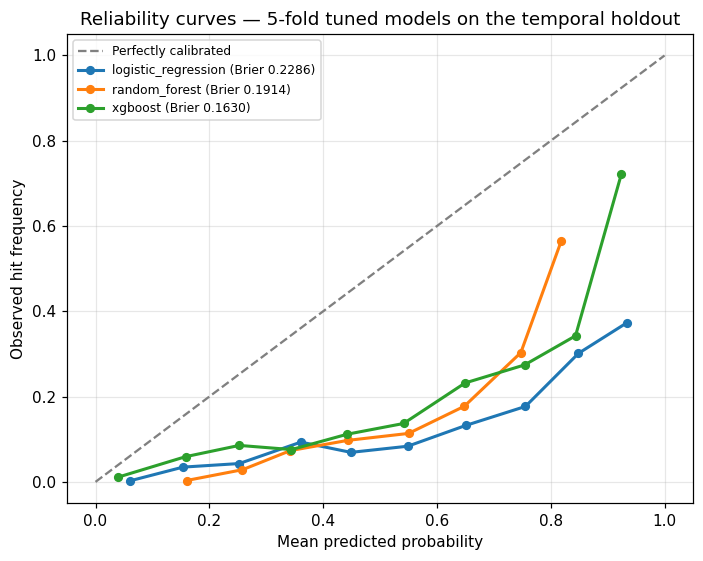

,brier_score
model,
xgboost,0.1630
random_forest,0.1914
logistic_regression,0.2286


In [9]:
calibration = calibration_table(fitted, x_test, y_test)
briers = calibration.groupby("model")["brier_score"].first().sort_values()

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Perfectly calibrated")
for name, group in calibration.groupby("model"):
    ax.plot(group["predicted_probability"], group["observed_frequency"],
            marker="o", ms=5, lw=2, label=f"{name} (Brier {briers[name]:.4f})")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed hit frequency")
ax.set_title(f"Reliability curves — {FOLDS}-fold tuned models on the temporal holdout")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "calibration_curves.png", bbox_inches="tight")
plt.show()

briers.to_frame("brier_score").round(4)

Points below the diagonal indicate over-confidence: the model predicts a higher hit probability
than the observed frequency justifies.

## 7. Phase 4 — fairness across genre sub-groups (H3)

Per-genre metrics are computed, then filtered by minimum group size. The filter is essential:
without it most groups contain one or two tracks and score exactly 0.0 or 1.0, which swamps any
real disparity.

In [10]:
pred = best_model.predict(x_test)
prob = best_model.predict_proba(x_test)[:, 1]

eval_df = pd.DataFrame({
    "y_true": y_test.to_numpy(), "y_pred": pred, "y_score": prob,
    "genre": x_test["genre"].to_numpy() if "genre" in x_test.columns else "unknown",
})

groups = metrics_by_group(eval_df, "y_true", "y_pred", "genre")
summary = fairness_summary(groups, MIN_GROUP_N)
pd.DataFrame([summary]).T.rename(columns={0: "value"})

,value
min_n,30
groups_total,145
groups_kept,19
groups_excluded,126
excluded_with_perfect_f1,102
f1_best_group,baton rouge rap
f1_best,1.0
f1_worst_group,r&b
f1_worst,0.258694
f1_disparity,0.741306


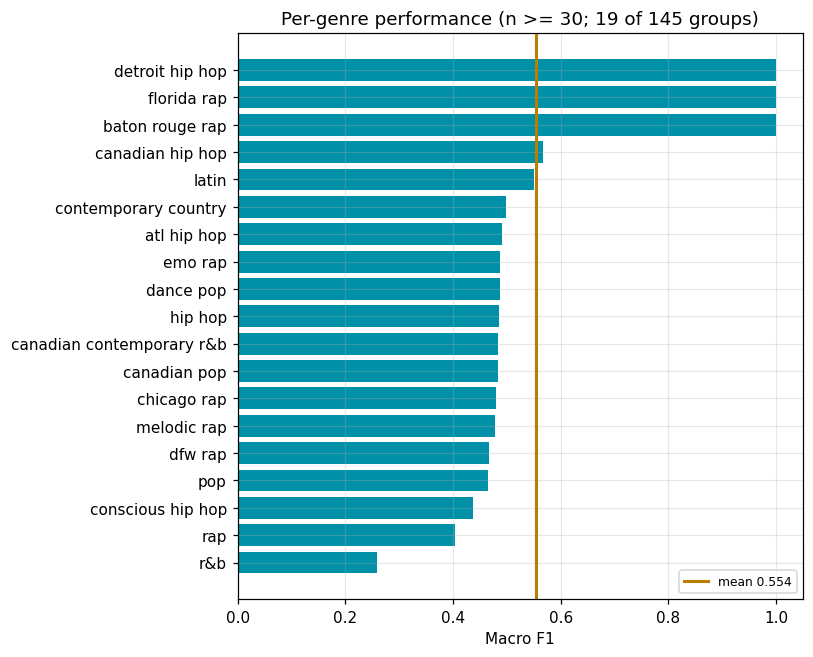

In [11]:
kept = groups[groups["n_samples"] >= MIN_GROUP_N].sort_values("f1_macro")

fig, ax = plt.subplots(figsize=(7.5, max(3.2, 0.32 * len(kept))))
ax.barh(kept["group"].astype(str), kept["f1_macro"], color="#0090a7")
ax.axvline(kept["f1_macro"].mean(), color="#ba7f00", lw=2,
           label=f"mean {kept['f1_macro'].mean():.3f}")
ax.set_xlabel("Macro F1")
ax.set_title(f"Per-genre performance (n >= {MIN_GROUP_N}; {len(kept)} of {len(groups)} groups)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "genre_fairness.png", bbox_inches="tight")
plt.show()

## 8. Hypothesis verdicts

Stated against the numbers produced above rather than against expectation.

In [12]:
majority = baselines_df.loc["baseline_majority_class"]
random_b = baselines_df.loc["baseline_stratified_random"]
best_acc = tuned_df["accuracy"].max()
best_f1  = tuned_df["f1_macro"].max()

print("H1  accuracy > 70%, outperforming a random baseline")
print(f"      best tuned accuracy   {best_acc:.4f}")
print(f"      stratified random     {random_b['accuracy']:.4f}")
print(f"      majority class        {majority['accuracy']:.4f}")
print(f"      exceeds 70%?          {'YES' if best_acc > 0.70 else 'NO'}")
print(f"      beats random?         {'YES' if best_acc > random_b['accuracy'] else 'NO'}")
print(f"      beats majority?       {'YES' if best_acc > majority['accuracy'] else 'NO'}")
print(f"      macro F1 {best_f1:.4f} vs majority {majority['f1_macro']:.4f}"
      f"  -> {'model wins on the imbalance-aware metric' if best_f1 > majority['f1_macro'] else 'model loses'}")

print("\nH2  ensembles outperform logistic regression")
ranked = tuned_df.sort_values("cv_f1_macro_mean", ascending=False)
for _, r in ranked.iterrows():
    print(f"      {r['model']:22} CV {r['cv_f1_macro_mean']:.4f} +/- {r['cv_f1_macro_std']:.4f}"
          f"   holdout f1 {r['f1_macro']:.4f}")
lr = tuned_df[tuned_df["model"] == "logistic_regression"].iloc[0]
ens = tuned_df[tuned_df["model"] != "logistic_regression"]
win = ens.loc[ens["cv_f1_macro_mean"].idxmax()]
margin = win["cv_f1_macro_mean"] - lr["cv_f1_macro_mean"]
noise = win["cv_f1_macro_std"] + lr["cv_f1_macro_std"]
print(f"      best ensemble ({win['model']}) - LR = {margin:+.4f}, combined std {noise:.4f}")
print(f"      verdict: {'SUPPORTED' if margin > noise else 'NOT SUPPORTED (within fold noise)'}")

print("\nH3  measurable genre disparities")
print(f"      groups at n>={MIN_GROUP_N}: {summary['groups_kept']} of {summary['groups_total']}")
print(f"      best  {summary['f1_best_group']}  {summary['f1_best']:.4f}")
print(f"      worst {summary['f1_worst_group']}  {summary['f1_worst']:.4f}")
print(f"      disparity {summary['f1_disparity']:.4f} (mean {summary['f1_mean']:.4f},"
      f" sd {summary['f1_std']:.4f})")
print(f"      verdict: {'SUPPORTED' if summary['f1_disparity'] > 0.1 else 'NOT SUPPORTED'}")

H1  accuracy > 70%, outperforming a random baseline
      best tuned accuracy   0.7732
      stratified random     0.7406
      majority class        0.8910
      exceeds 70%?          YES
      beats random?         YES
      beats majority?       NO
      macro F1 0.6024 vs majority 0.4712  -> model wins on the imbalance-aware metric

H2  ensembles outperform logistic regression
      xgboost                CV 0.6683 +/- 0.0097   holdout f1 0.6024
      random_forest          CV 0.6628 +/- 0.0106   holdout f1 0.5876
      logistic_regression    CV 0.6439 +/- 0.0059   holdout f1 0.5496
      best ensemble (xgboost) - LR = +0.0244, combined std 0.0155
      verdict: SUPPORTED

H3  measurable genre disparities
      groups at n>=30: 19 of 145
      best  baton rouge rap  1.0000
      worst r&b  0.2587
      disparity 0.7413 (mean 0.5540, sd 0.2078)
      verdict: SUPPORTED


### Limitations to carry into the write-up

* Dropping the impossible-date rows removes a large share of the source data; the surviving
  sample may not be representative of the excluded portion.
* `spotify_genre` and `genre` are stored as stringified lists with very high cardinality, so
  one-hot encoding produces thousands of sparse columns and genre combinations dominate the
  feature-importance ranking.
* Roughly one row in six has no audio features at all and is carried by median imputation.
* The Spotify Web API no longer exposes `preview_url` or audio features to newly created
  applications, so the dataset is pre-collected rather than gathered live. The Librosa
  extraction path in `src/audio_features.py` and the local-audio training route exist as the
  adopted workaround.
* The Million Song Dataset supplement described in the proposal was not integrated.